# Radial tree

Notebook as a proof of concept for creating a radial tree diagram using only numpy, matplotlib and bezier curves.

Disclaimer: Code is not pretty, probably needs a good amount of refactoring :D

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

## Load data

Data comes from [Information is Beautiful](https://informationisbeautiful.net/visualizations/which-is-the-best-performing-marvel-movie/) via [Makeover Monday 2024 Week 16](https://data.world/makeovermonday/what-is-the-best-performing-marvel-movie)

In [ ]:
#load data
df = pd.read_csv("best_performing_marvel_movie.csv")

In [3]:
df.columns

Index(['film', 'category', 'worldwide gross ($m)', '% budget recovered',
       'critics % score', 'audience % score', 'audience vs critics % deviance',
       'budget ($m)', 'domestic gross ($m)', 'international gross ($m)',
       'opening weekend ($m)', 'second weekend ($m)',
       '1st vs 2nd weekend drop off', '% gross from opening weekend',
       '% gross from domestic', '% gross from international',
       '% budget opening weekend', 'year', 'source'],
      dtype='object')

In [4]:
#convert into floats
percentage_columns = ['% budget recovered',  'critics % score', 'audience % score', 
                    'audience vs critics % deviance',  '1st vs 2nd weekend drop off',
                    '% gross from opening weekend',
                     '% gross from domestic', '% gross from international',
                    '% budget opening weekend']
for column in percentage_columns:
    df[column] = df[column].str.replace("%", "").astype(float)

In [5]:
df.head()

,film,category,worldwide gross ($m),% budget recovered,critics % score,audience % score,audience vs critics % deviance,budget ($m),domestic gross ($m),international gross ($m),opening weekend ($m),second weekend ($m),1st vs 2nd weekend drop off,% gross from opening weekend,% gross from domestic,% gross from international,% budget opening weekend,year,source
0,Ant-Man,Ant-Man,518,398.0,83.0,85.0,-2.0,130.0,180,338,57.0,24.0,-58.0,31.8,34.7,65.3,43.8,2015,https://www.the-numbers.com/movie/Ant-Man#tab=...
1,Ant-Man & The Wasp,Ant-Man,623,479.0,87.0,80.0,7.0,130.0,216,406,75.8,29.0,-62.0,35.0,34.7,65.2,58.3,2018,https://www.the-numbers.com/movie/Ant-Man-and-...
2,Avengers: Age of Ultron,Avengers,1395,382.0,76.0,82.0,-6.0,365.0,459,936,191.0,77.0,-60.0,41.7,32.9,67.1,52.3,2015,https://www.the-numbers.com/movie/Avengers-Age...
3,Avengers: End Game,Avengers,2797,699.0,94.0,90.0,4.0,400.0,858,1939,357.0,147.0,-59.0,41.6,30.7,69.3,89.3,2019,https://www.the-numbers.com/movie/Avengers-End...
4,Avengers: Infinity War,Avengers,2048,683.0,85.0,91.0,-6.0,300.0,678,1369,257.0,114.0,-56.0,38.0,33.1,66.8,85.7,2018,https://www.the-numbers.com/movie/Avengers-Inf...


## Explore

In [6]:
variable = "worldwide gross ($m)"
method = "mean"
series = df.groupby(["category"]).agg({variable:method, "film": "nunique"}).astype(int).sort_values(by=variable, ascending=False)
series.reset_index()

,category,worldwide gross ($m),film
0,Avengers,1938,4
1,Spider-Man,1307,3
2,Black Panther,1095,2
3,Guardians,819,2
4,Dr Strange,814,2
5,Iron Man,807,3
6,Captain America,745,3
7,Thor,672,4
8,Ant-Man,570,2
9,Unique,521,5


In [7]:
film = df.groupby(["category", "film"]).agg({variable:method}).astype(int).sort_values(by=variable, ascending=False)
film = pd.merge(film.reset_index(), 
                series.reset_index()[["category", variable]].rename(columns={variable: variable+"_mean"}), 
                left_on="category", right_on="category", how="left" )
film = film.sort_values(by=[variable+"_mean", variable], ascending=False)
film

,category,film,worldwide gross ($m),worldwide gross ($m)_mean
0,Avengers,Avengers: End Game,2797,1938
1,Avengers,Avengers: Infinity War,2048,1938
3,Avengers,The Avengers,1515,1938
4,Avengers,Avengers: Age of Ultron,1395,1938
2,Spider-Man,Spider-Man: No Way Home,1911,1307
8,Spider-Man,Spider-Man: Far from Home,1132,1307
11,Spider-Man,Spider-Man: Homecoming,878,1307
5,Black Panther,Black Panther,1336,1095
13,Black Panther,Black Panther 2,855,1095
12,Guardians,Guardians of the Galaxy 2,869,819


## Data viz

In [262]:
#Styles ------------------------------

#colors
cat_colors_dict = {'Avengers': "#E10711",
            'Spider-Man': "#F9A505",
            'Black Panther' : "#E0C603",
             'Guardians' : "#67C04A",
            'Dr Strange' : "#25B5BF",
            'Iron Man' : "#009EDD",
            'Captain America': "#3754E4",
            'Thor' : "#8D2D99",
            'Ant-Man' : "#DC448E",
            'Unique' : "#878787"}

colors_dict = {"bg": "#111111",
          "text": "#EAEAEA",
          "lines" : "#666666",
          "leg_fill" : "#393636",
          "leg_outline": "#9E9E9E"}

#nice labels
labels_list = ['Avengers',
                'Spider-Man',
                'Black\nPanther',
                'Guardians',
                 'Dr Strange',
                 'Iron Man',
                 'Captain\nAmerica',
                'Thor',
                 'Ant-Man',
                'Unique']

#fonts
from matplotlib import font_manager
title_font = font_manager.FontProperties(fname='C:\\WINDOWS\\Fonts\\Bangers.ttf')
subtitle_font = font_manager.FontProperties(fname='C:\\WINDOWS\\Fonts\\open-sans-condensed.bold.ttf')
label_font = font_manager.FontProperties(fname='C:\\WINDOWS\\Fonts\\Gudea-Bold.ttf')
legend_font = font_manager.FontProperties(fname='C:\\WINDOWS\\Fonts\\Gudea-Regular.ttf')

In [ ]:
#prepare data
variable = "worldwide gross ($m)"
method = "mean"
series = df.groupby(["category"]).agg({variable:method, "film": "nunique"}).astype(int).sort_values(by=variable, ascending=False)
film = df.groupby(["category", "film"]).agg({variable:method}).astype(int).sort_values(by=variable, ascending=False)
film = pd.merge(film.reset_index(), 
                series.reset_index().rename(columns={variable: variable+"_mean", "film": "film_no"}), 
                left_on="category", right_on="category", how="left" )
film["colors"] = film["category"].map(cat_colors_dict)
film = film.sort_values(by=[variable+"_mean", variable], ascending=False)

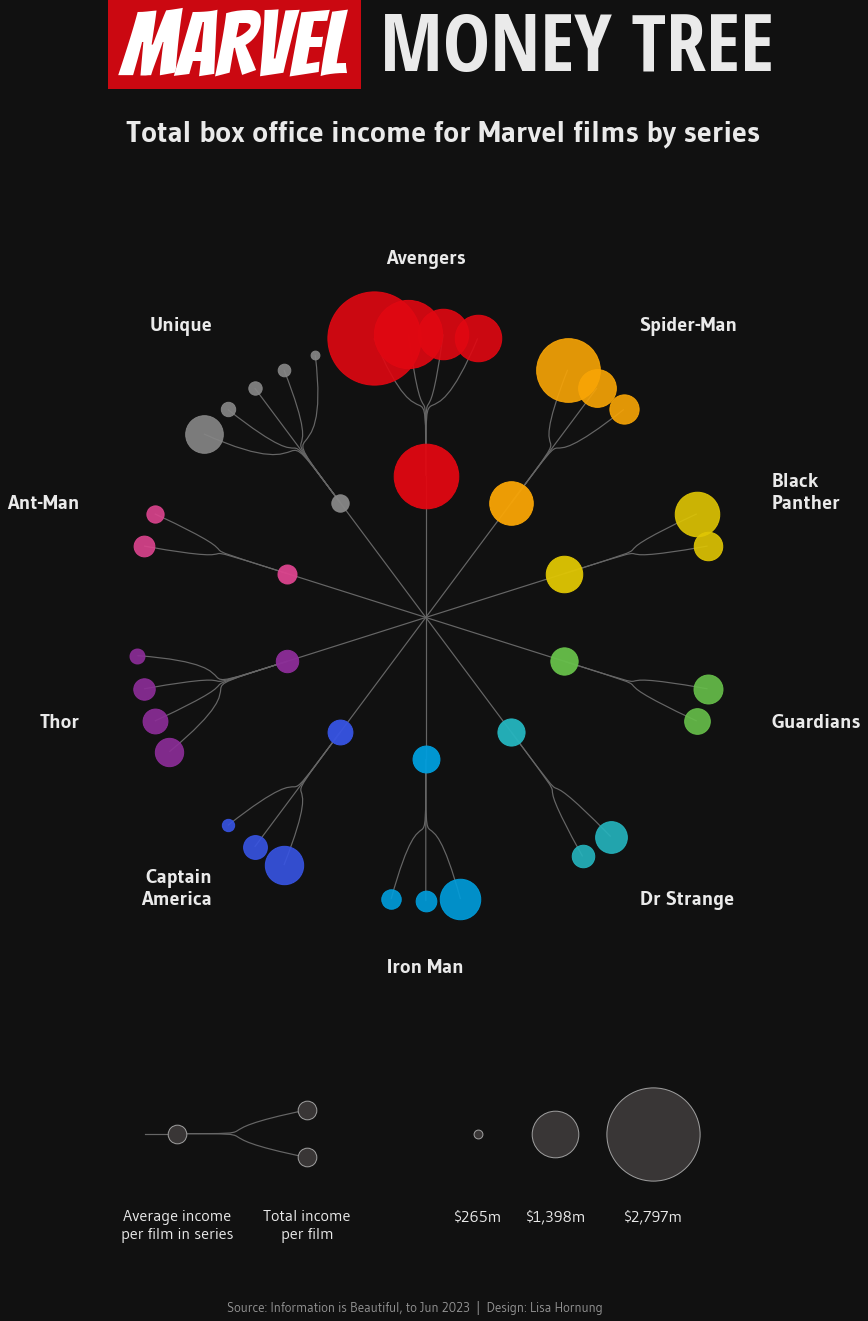

In [263]:
#calculate positions on the inner circle ---------------
def calculate_positions(radius, num_elements, start_angle=np.pi / 2):
    angles = np.linspace(start_angle, start_angle - 2 * np.pi, num_elements, endpoint=False)
    x_positions = radius * np.cos(angles)
    y_positions = radius * np.sin(angles)
    return x_positions, y_positions, angles

#calculate positions on the outer circle ---------------
def calculate_subcategory_positions(parent_angle, outer_radius, num_subcategories, total_categories, subcategory_spacing=0.19):
    angle_width = (2 * np.pi) / total_categories
    sub_angle_width = angle_width * subcategory_spacing
    start_angle = parent_angle + (sub_angle_width * (num_subcategories - 1) / 2)
    sub_angles = np.linspace(start_angle, start_angle - sub_angle_width * (num_subcategories - 1), num_subcategories)
    sub_x_positions = outer_radius * np.cos(sub_angles)
    sub_y_positions = outer_radius * np.sin(sub_angles)
    return sub_x_positions, sub_y_positions, sub_angles

#Parameters-----------------
inner_radius = 10
bezier_radius1 = inner_radius*1.9  
bezier_radius2 = inner_radius*1.1
outer_radius = inner_radius*2
label_radius = outer_radius *1.25
num_categories = len(series)
linewidth = 1.2
label_ha_pos = ["center", "left", "left", "left", "left", "center", "right", "right", "right", "right"]
norm = 30

#get marker sizes
category_marker_sizes = film[["category", variable+"_mean"]].drop_duplicates()[variable+"_mean"].values / norm
subcategory_counts = film[["category", "film_no"]].drop_duplicates()["film_no"].values
subcategory_marker_sizes = []
for category in film["category"].unique():
    subcategory_marker_sizes.append(film[film["category"]==category][variable].values / norm)
cat_colors = cat_colors_dict.values()

#get positions
x_inner, y_inner, inner_angles = calculate_positions(inner_radius, num_categories)
x_bezier1, y_bezier1, bezier_angle1 = calculate_positions(bezier_radius1, num_categories)
x_bezier2, y_bezier2, bezier_angle2 = calculate_positions(bezier_radius2, num_categories)

# Plot ----------------------------------
fig, ax = plt.subplots(figsize=(12, 12))
fig.set_facecolor(colors_dict["bg"])

#plot categories in inner circle
for i, (xi, yi, ms, angle, xib1, yib1, xib2, yib2, color) in enumerate(
    zip(x_inner, y_inner, category_marker_sizes, inner_angles, 
        x_bezier1, y_bezier1, x_bezier2, y_bezier2, cat_colors)):
    ax.plot(xi, yi, 'o', markersize=ms, zorder=3, color=color, alpha=0.95)
    ax.plot([0, xi], [0, yi], color=colors_dict["lines"], linewidth=linewidth, zorder=2)  

    # Calculate subcategory positions for each inner circle element
    sub_x, sub_y, sub_angles = calculate_subcategory_positions(
        angle, outer_radius, subcategory_counts[i], num_categories)
    
    # Plot subcategory elements
    for sx, sy, sub_angle, ms in zip(
        sub_x, sub_y, sub_angles, subcategory_marker_sizes[i]):
        ax.plot(sx, sy, 'o', markersize=ms, zorder=3, color=color, alpha=0.9)

        #plot bezier curves from category to subcategory element
        indent = 2
        verts = [(xi, yi), (xib1, yib1), (xib2,yib2), (sx, sy)] 
        codes = [Path.MOVETO] + [Path.CURVE4] * 3
        path = Path(verts, codes)
        patch = patches.PathPatch(path, facecolor='none',
                                  edgecolor=colors_dict["lines"], 
                                  linewidth=linewidth, 
                                  zorder=2)
        ax.add_patch(patch)

#format axis--------------------------
axis_offset = 3
ax.set_xlim(-outer_radius - axis_offset, outer_radius + axis_offset)
ax.set_ylim(-outer_radius - axis_offset, outer_radius + axis_offset)
ax.axis("off")

#category labels ----------------------
x_labels, y_labels, label_angles = calculate_positions(label_radius, num_categories)
for i,  (xil, yil, ha_pos, label) in enumerate(zip(x_labels, y_labels, label_ha_pos,labels_list)):
    ax.text(xil, yil, label, ha=ha_pos, 
            color=colors_dict["text"], fontsize=20,
            fontproperties=label_font)

#legends--------------------------------

#axes to hold sized markers
msaxes = fig.add_axes([0.55, -0.15, 0.3, 0.11]) 
kw = dict(zorder=1, markerfacecolor=colors_dict["leg_fill"], markeredgecolor=colors_dict["leg_outline"],
          alpha=1, clip_on=False,)
legend_markersizes = [film[variable].min(), film[variable].max()/2, film[variable].max()]
for i, (x, y, size) in enumerate(zip([0.3, 1.5, 3], [0]*3, legend_markersizes)):
    msaxes.plot(x, y, 'o', markersize=size/norm, **kw)
    msaxes.text(x,-1.6, "${:,.0f}m".format(int(size)), fontproperties=legend_font,
                fontsize=16,  va="top",
                color=colors_dict["text"], clip_on=False, zorder=2, ha="center")
msaxes.set_xlim(0,4)
msaxes.set_ylim(ymin=-1, ymax=1)
msaxes.axis("off")

#axes to hold tree hierarchy
traxes = fig.add_axes([0.15, -0.15, 0.3, 0.11]) 
kw = dict(zorder=1, markerfacecolor=colors_dict["leg_fill"], markeredgecolor=colors_dict["leg_outline"],
          alpha=1, clip_on=False, ms=film[variable].max()/5 / norm)
for i, (x, y, size) in enumerate(zip([1, 3, 3], [0, 0.5, -0.5], legend_markersizes)):
    traxes.plot(x, y, 'o', **kw)
traxes.plot([0.5,1], [0,0], linewidth=linewidth, color=colors_dict["lines"], zorder=0)
traxes_offset = 0.2
verts1 = [(1, 0), (1+traxes_offset*8, 0), (1+traxes_offset,0), (3, 0.5)] 
verts2 = [(1, 0), (1+traxes_offset*8, 0), (1+traxes_offset,0), (3, -0.5)] 
codes = [Path.MOVETO] + [Path.CURVE4] * 3
for verts in [verts1, verts2]:
    path = Path(verts, codes)
    patch = patches.PathPatch(path, facecolor='none',
                            edgecolor=colors_dict["lines"], 
                            linewidth=linewidth, 
                            zorder=0)   
    traxes.add_patch(patch)
kw=dict(fontproperties=legend_font, fontsize=16, ha="center", va="top", clip_on=False, color=colors_dict["text"])
traxes.text(1, -1.6, "Average income\nper film in series", **kw)
traxes.text(3, -1.6, "Total income\nper film", **kw)
traxes.set_xlim(0,4)
traxes.set_ylim(ymin=-1, ymax=1)
traxes.axis("off")

#title-------------------------------
plt.figtext(0.16, 1.17, "Marvel".upper(), color="white", fontsize=90, fontproperties=title_font,
         va="center", bbox=dict(facecolor=cat_colors_dict["Avengers"], 
                             edgecolor='none',boxstyle="square", pad=0.15, alpha=0.9))
plt.figtext(0.46, 1.16, "Money tree".upper(), color=colors_dict["text"], 
            fontsize=80, fontproperties=subtitle_font, va="center")
plt.figtext(0.165, 1.055, "Total box office income for Marvel films by series", color=colors_dict["text"], 
            fontsize=30, fontproperties=label_font, ha="left")
plt.figtext(0.5, -0.3, "Source: Information is Beautiful, to Jun 2023  |  Design: Lisa Hornung", 
            color=colors_dict["text"], fontsize=13, fontproperties=legend_font,
            ha="center", alpha=0.6)

#export
#fig.savefig("Marvel_movies_revenue.svg")
plt.savefig("Marvel_movies_box_office_income.png",  bbox_inches='tight', pad_inches=2)

plt.show()

## Playground

In [ ]:
pivot = df.groupby(["intake_type_dv","animal_type_dv"])["animal_id"].count().unstack()
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values(by="total", ascending=False)
for column in pivot.columns:
    pivot.loc["total", column] = pivot[column].sum()
column_sort = pivot.loc["total"].sort_values(ascending=False).index[1:].to_list() + ["total"]
pivot.columns = column_sort
pivot

,cat,dog,bird,wild,other,rabbit,reptile,guinea pig,total
intake_type_dv,,,,,,,,,
stray,211.0,12761.0,7407.0,82.0,122.0,348.0,173.0,22.0,21126.0
wildlife,1800.0,NaN,1.0,1.0,1140.0,43.0,102.0,1386.0,4473.0
owner surrender,33.0,948.0,1343.0,74.0,60.0,128.0,28.0,1.0,2615.0
welfare seized,13.0,141.0,318.0,2.0,4.0,1.0,3.0,2.0,484.0
confiscate,6.0,57.0,310.0,13.0,2.0,4.0,6.0,1.0,399.0
return,NaN,127.0,177.0,NaN,NaN,2.0,NaN,NaN,306.0
quarantine,NaN,19.0,143.0,NaN,NaN,NaN,NaN,NaN,162.0
safe keep,NaN,16.0,65.0,NaN,17.0,NaN,32.0,NaN,130.0
other,12.0,76.0,4.0,NaN,NaN,NaN,NaN,NaN,92.0


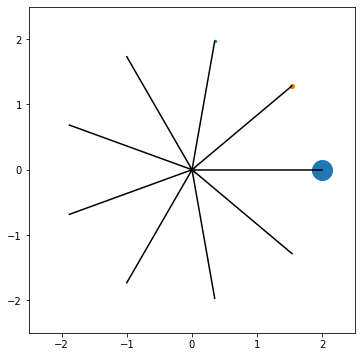

In [ ]:

#calculate positions on the circle ---------------
def calculate_positions(radius, num_elements):
    angles = np.linspace(0, 2 * np.pi, num_elements, endpoint=False)
    x_positions = radius * np.cos(angles)
    y_positions = radius * np.sin(angles)
    return x_positions, y_positions

radius = 2  
num_elements = 9  
x, y = calculate_positions(radius, num_elements)

# Normalize counts to a reasonable marker size range
counts = pivot["total"][:-1].astype(int).values
marker_sizes = (counts - counts.min()) / (counts.max() - counts.min()) * 20
 

# Plot ----------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(0, 0, 'rx')  # Center point

#plot elements
for xi, yi, ms in zip(x,y, marker_sizes):
    ax.plot(xi, yi, 'o', markersize=ms) 
    ax.plot([0, xi], [0, yi], 'k-') 



ax.set_xlim(-radius - 0.5, radius + 0.5)
ax.set_ylim(-radius - 0.5, radius + 0.5)
ax.set_aspect('equal')

plt.show()

In [33]:
df.groupby(["intake_type_dv"])["animal_id"].count()

intake_type_dv
confiscate           399
other                 92
owner surrender     2615
quarantine           162
return               306
safe keep            130
stray              21126
welfare seized       484
wildlife            4473
Name: animal_id, dtype: int64

In [25]:
df["animal_type_dv"] = df["animal_type"].str.replace("livestock", "other").str.replace("amphibian", "other")

In [32]:
df["intake_type_dv"] = df["intake_type"].str.replace("adopted animal return", "other").str.replace(
    "foster", "other").str.replace("euthenasia required", "other").str.replace("trap, neuter, return", "other")

In [12]:
df[df["primary_color"]=="tan"]

,animal_id,animal_name,animal_type,primary_color,secondary_color,sex,dob,intake_date,intake_condition,intake_type,...,outcome_date,crossing,jurisdiction,outcome_type,outcome_subtype,latitude,longitude,outcome_is_dead,was_outcome_alive,geopoint
42,A603548,NaN,dog,tan,white,Male,2014-02-08,2018-02-08,normal,stray,...,2018-02-14,"10 BLK W BORT ST, LONG BEACH, CA 90805",Long Beach,transfer,spcala,33.870346,-118.202016,False,True,"33.8703458, -118.2020155"
93,A605399,happy,dog,tan,NaN,Neutered,2007-03-27,2018-03-27,injured mild,stray,...,2018-03-31,"100 BLK CHERRY AVE, LONG BEACH, CA 90802",Long Beach,euthanasia,ill severe,33.765221,-118.167597,True,False,"33.7652208, -118.1675969"
132,A706704,NaN,dog,tan,NaN,Female,2018-09-12,2023-09-12,injured severe,stray,...,2023-09-13,"100 BLK E DEL AMO, LB 90805",Long Beach,euthanasia,at vet,33.846550,-118.193757,True,False,"33.8465498, -118.1937565"
150,A606752,NaN,dog,tan,white,Male,2017-11-26,2018-04-26,normal,stray,...,2018-05-02,"100 BLK E OSGOOD ST, LONG BEACH, CA 90805",Long Beach,transfer,spcala,33.863438,-118.193933,False,True,"33.8634376, -118.1939327"
170,A692018,snow,dog,tan,black,Neutered,2020-01-19,2023-01-19,normal,stray,...,2023-05-24,"100 BLK LONG BEACH BLVD, LB CA 90802",Long Beach,adoption,web,33.768301,-118.188740,False,True,"33.7683013, -118.1887403"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29777,A590968,*jammer,dog,tan,white,Male,2013-05-28,2017-05-28,normal,stray,...,2017-06-04,"WINDJAMMER RD / WINDWARD AVE, CERRITOS, CA 90703",Cerritos,transfer,spcala,33.877198,-118.095875,False,True,"33.8771982, -118.0958749"
29779,A603006,NaN,dog,tan,NaN,Male,2017-03-24,2018-01-24,normal,stray,...,2018-01-31,"WOODRUFF AVE / E CARSON ST, LONG BEACH, CA 90808",Long Beach,transfer,spcala,33.832336,-118.116539,False,True,"33.8323363, -118.1165386"
29780,A596730,*athena,dog,tan,white,Female,2009-09-08,2017-09-08,ill mild,stray,...,2017-09-29,"WOODRUFF AVE / E MONLACO RD, LONG BEACH, CA 90808",Long Beach,rescue,kittykatch,33.822297,-118.116472,False,True,"33.8222973, -118.1164717"
29783,A607648,*betsie,dog,tan,black,Female,2015-12-16,2018-05-16,normal,stray,...,2018-05-22,"WOODRUFF AVE / E WILLOW ST, LONG BEACH, CA 90815",Long Beach,transfer,spcala,33.803196,-118.114522,False,True,"33.803196, -118.1145217"
